H0: Различные подходы к группировке данных и обработке выбросов излишние и не влияют на качество прогноза, так как используется экспоненциальное взвешивание ряда

H1: Различные подходы к группировке данных и обработке выбросов влияют на качество прогноза несмотря на использование экспоненциального взвешивания

Возможные группы:
1. "A" - группировка через среднее, обработка выбросов
2. "B" - группировка через медиану, отсутствие обработки выбросов
3. "C" - группировка через медиану, обработка выбросов
4. "D" - группировка через среднее, отсутствие обработки выбросов

Статистика: 
1. ANOVA для зависимых выборок \ либо непараметрический аналог теста
2. Попарный t-test для зависимых выборок \ либо непараметрический аналог теста

Уровень значимости: 5%

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [ ]:
a_df = pd.read_csv('a_group.csv', index_col=0).sort_index()
b_df = pd.read_csv('b_group.csv', index_col=0).sort_index()
c_df = pd.read_csv('c_group.csv', index_col=0).sort_index()
d_df = pd.read_csv('d_group.csv', index_col=0).sort_index()
df_ = pd.concat(
    (
        a_df[['date', 'product', 'product_type', 'federal_okrug', 'price']].rename(columns={'price':'a'}),
        b_df['price'].rename('b'),
        c_df['price'].rename('c'),
        d_df['price'].rename('d')
    ),
    axis=1
)

In [4]:
df = pd.read_csv('true_data.csv', index_col=0)
df['product'], df['product_type'], df['federal_okrug'] = zip(*df['ID'].apply(lambda x: x.split('|')))
df = df.drop('ID', axis=1)
df = df.rename(columns={'ds':'date'})

In [5]:
df = pd.merge(df_, df, how='left', on=['date', 'product', 'product_type', 'federal_okrug'])
df

,date,product,product_type,federal_okrug,a,b,c,d,y
0,2024-07-01,Говядина,вырезка,Москва,1601.96,1626.94,1625.59,1601.68,1586.99
1,2024-07-08,Говядина,вырезка,Москва,1596.94,1629.29,1626.83,1596.70,1604.49
2,2024-07-15,Говядина,вырезка,Москва,1591.57,1625.66,1622.30,1591.40,1678.72
3,2024-07-22,Говядина,вырезка,Москва,1580.72,1622.39,1618.25,1580.64,1670.84
4,2024-07-29,Говядина,вырезка,Москва,1575.84,1619.31,1614.50,1575.89,1669.01
...,...,...,...,...,...,...,...,...,...
4045,2024-12-23,Свинина,шея,ВСЕ,407.71,409.19,408.03,408.75,426.53
4046,2024-12-30,Свинина,шея,ВСЕ,408.84,410.57,410.09,409.56,406.53
4047,2025-01-06,Свинина,шея,ВСЕ,408.99,410.93,410.96,409.46,386.53
4048,2025-01-13,Свинина,шея,ВСЕ,407.63,409.24,409.64,407.92,423.44


In [7]:
df['mape_a'] = np.abs((df['y'] - df['a']) / df['y']) * 100
df['mape_b'] = np.abs((df['y'] - df['b']) / df['y']) * 100
df['mape_c'] = np.abs((df['y'] - df['c']) / df['y']) * 100
df['mape_d'] = np.abs((df['y'] - df['d']) / df['y']) * 100

In [8]:
df

,date,product,product_type,federal_okrug,a,b,c,d,y,mape_a,mape_b,mape_c,mape_d
0,2024-07-01,Говядина,вырезка,Москва,1601.96,1626.94,1625.59,1601.68,1586.99,0.943295,2.517344,2.432277,0.925652
1,2024-07-08,Говядина,вырезка,Москва,1596.94,1629.29,1626.83,1596.70,1604.49,0.470555,1.545662,1.392343,0.485513
2,2024-07-15,Говядина,вырезка,Москва,1591.57,1625.66,1622.30,1591.40,1678.72,5.191455,3.160742,3.360894,5.201582
3,2024-07-22,Говядина,вырезка,Москва,1580.72,1622.39,1618.25,1580.64,1670.84,5.393694,2.899739,3.147519,5.398482
4,2024-07-29,Говядина,вырезка,Москва,1575.84,1619.31,1614.50,1575.89,1669.01,5.582351,2.977813,3.266008,5.579355
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4045,2024-12-23,Свинина,шея,ВСЕ,407.71,409.19,408.03,408.75,426.53,4.412351,4.065365,4.337327,4.168523
4046,2024-12-30,Свинина,шея,ВСЕ,408.84,410.57,410.09,409.56,406.53,0.568224,0.993777,0.875704,0.745332
4047,2025-01-06,Свинина,шея,ВСЕ,408.99,410.93,410.96,409.46,386.53,5.810674,6.312576,6.320337,5.932269
4048,2025-01-13,Свинина,шея,ВСЕ,407.63,409.24,409.64,407.92,423.44,3.733705,3.353486,3.259021,3.665218


In [9]:
a = df['mape_a'].values
b = df['mape_b'].values
c = df['mape_c'].values
d = df['mape_d'].values

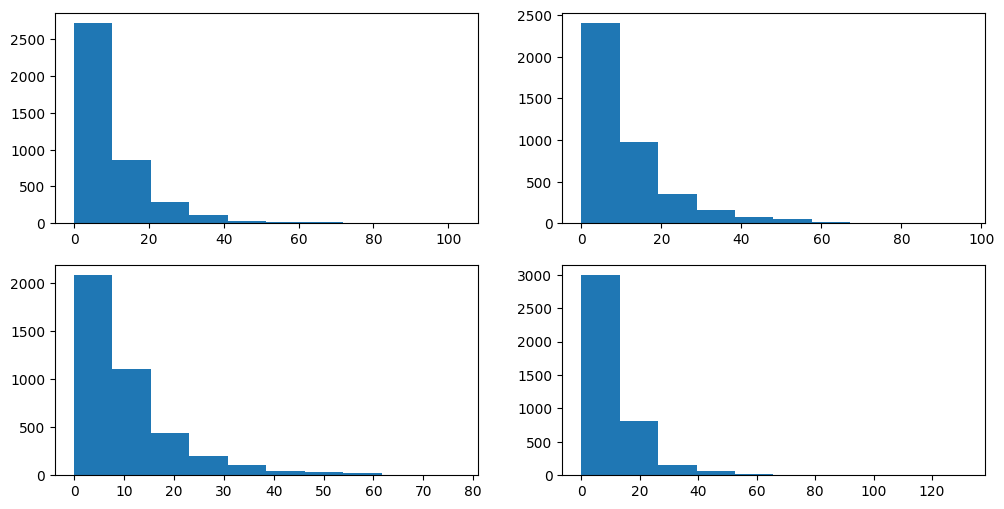

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.reshape(-1)
for i, dist in enumerate([a, b, c, d]):
    ax[i].hist(dist)

plt.show()

Посмотрим на среднее и медиану выборок, чтобы определить лучшую

In [32]:
print(f'среднее: {round(np.mean(a), 2)} медиана: {round(np.median(a), 2)} | A - группировка через среднее, обработка выбросов.')
print(f'среднее: {round(np.mean(b), 2)} медиана: {round(np.median(b), 2)} | B - группировка через медиану, отсутствие обработки выбросов.')
print(f'среднее: {round(np.mean(c), 2)} медиана: {round(np.median(c), 2)} | C - группировка через медиану, обработка выбросов.')
print(f'среднее: {round(np.mean(d), 2)} медиана: {round(np.median(d), 2)} | D - группировка через среднее, отсутствие обработки выбросов.')

среднее: 9.63 медиана: 6.62 | A - группировка через среднее, обработка выбросов.
среднее: 11.17 медиана: 7.55 | B - группировка через медиану, отсутствие обработки выбросов.
среднее: 10.54 медиана: 7.43 | C - группировка через медиану, обработка выбросов.
среднее: 10.06 медиана: 7.05 | D - группировка через среднее, отсутствие обработки выбросов.


In [15]:
from scipy.stats import friedmanchisquare, wilcoxon

Так как распределения ненормальные, используем непараметрический тест для зависимых выборок.

Хи^2 Фридмана проверяет гипотезу что зависимые выборки имеют одинаковое распределение

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.friedmanchisquare.html

Friedman test for repeated samples. 

The Friedman test tests the null hypothesis that repeated samples of the same individuals have the same distribution.

In [16]:
pvalue = friedmanchisquare(a, b, c, d).pvalue
print(f'Вероятность пронаблюдать такие выборки, если бы они имели одинаковое распределение: {pvalue}')

Вероятность пронаблюдать такие выборки, если бы они имели одинаковое распределение: 2.675852024948079e-09


Можем отклонить нулевую гипотезу о том, что выборки из одинакового распределения. Значит распределения выборок отличаются между собой, осталось найти какие.

Нужно попарно сравнить распределения между собой, при этом учитывать поправку на множественную проверку гипотез.

Будем использовать поправку Бонферони $a = \frac{0.05}{k}$


Т-критерий Вилкоксона проверяет гипотезу, что две зависимые выборки имеют одинаковое распределение.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

Wilcoxon signed-rank test. The Wilcoxon signed-rank test tests the null hypothesis that two related paired samples come from the same distribution.

In [18]:
alpha = 0.05/6
alpha

0.008333333333333333

In [19]:
ab = wilcoxon(a, b).pvalue
ac = wilcoxon(a, c).pvalue
ad = wilcoxon(a, d).pvalue
bc = wilcoxon(b, c).pvalue
bd = wilcoxon(b, d).pvalue
cd = wilcoxon(c, d).pvalue

In [42]:
print(f'A и B имеют одинаковое распределение {ab > alpha}, p-value: {ab}')
print(f'A и C имеют одинаковое распределение {ac > alpha}, p-value: {ac}')
print(f'A и D имеют одинаковое распределение {ad > alpha}, p-value: {ad}')
print(f'B и C имеют одинаковое распределение {bc > alpha}, p-value: {bc}')
print(f'B и D имеют одинаковое распределение {bd > alpha}, p-value: {bd}')
print(f'C и D имеют одинаковое распределение {cd > alpha}, p-value: {cd}')

A и B имеют одинаковое распределение False, p-value: 6.5063210113255246e-12
A и C имеют одинаковое распределение False, p-value: 3.0934609626052627e-09
A и D имеют одинаковое распределение True, p-value: 0.0263200961986604
B и C имеют одинаковое распределение True, p-value: 0.6536505563351598
B и D имеют одинаковое распределение False, p-value: 3.984391158579439e-09
C и D имеют одинаковое распределение False, p-value: 0.004655823945482423


Можно сделать вывод, что группировка через среднее дает больший припрост к качеству, чем группировка через медиану.

Наличие или отсутствие обработки выбросов не имеет статистически значимого эффекта на качество.